# 12 — Landscape Patch Network

Convert the landscape type raster (from notebook 11) into a graph:
1. Connected-component labelling → spatially contiguous patches
2. Compute mean environmental features per patch
3. Build adjacency matrix from shared boundaries
4. Construct a NetworkX graph

**Input**: `landscape_types_30m.zarr` (~30 types from Ward clustering of SOM codebook)
**Output**: `landscape_graph.pkl` (NetworkX graph with node features and edges)

### Load data

In [1]:
import config
import gc
import json
import time
import numpy as np
import xarray as xr
import rioxarray
from s3_utils import load_zarr

# Landscape types from notebook 11
type_da = load_zarr(
    config.S3_PROCESSED + '/som/landscape_types_30m.zarr',
    name='landscape_type',
)
type_map = type_da.values
print(f'Landscape type map: {type_map.shape}')
print(f'Types: {len(np.unique(type_map[type_map >= 0]))} '
      f'(+ nodata), range [{type_map.min()}, {type_map.max()}]')

# Feature stack for node attributes
ds = load_zarr(config.FEATURE_STACK_ZARR)
with open('selected_features.json') as f:
    selected_features = json.load(f)
print(f'Features: {len(selected_features)}')


Landscape type map: (9010, 17810)
Types: 30 (+ nodata), range [-1, 29]
Features: 12


### Connected-component labelling

Each spatially contiguous region of the same landscape type becomes
a unique patch. With ~30 types (vs 4096 BMU IDs), patches are much
larger and more coherent.

In [2]:
from skimage.measure import label as sk_label

print('Connected-component labelling...')
t0 = time.time()

# sk_label treats 0 as background — shift so nodata=0
tm_shifted = type_map.astype(np.int32) + 1  # -1→0, 0→1, ...
patch_labels = sk_label(tm_shifted, connectivity=1, background=0)
patch_labels = patch_labels.astype(np.int32) - 1  # 0-based
patch_labels[type_map < 0] = -1  # restore nodata

n_patches = patch_labels.max() + 1
elapsed = time.time() - t0
print(f'Done in {elapsed:.1f}s')
print(f'Total patches: {n_patches:,}')


Connected-component labelling...
Done in 4.0s
Total patches: 15,846,733


### Merge small patches

Patches smaller than `MIN_PATCH_PIXELS` get absorbed into their largest
neighbour. Solved entirely in graph/dict space, then applied to the
160M pixel array in one vectorized pass.

In [3]:
MIN_PATCH_PIXELS = 100  # ~0.09 km² at 30 m

print(f'Patches before merge: {n_patches:,}')
t0 = time.time()

# --- 1. Build neighbour dict and counts in graph space ---
labels_flat = patch_labels.ravel()
counts = np.bincount(labels_flat[labels_flat >= 0], minlength=n_patches)

# Vectorized neighbour extraction
rows, cols = patch_labels.shape
nbrs = {i: set() for i in range(n_patches)}

for dy, dx in [(0, 1), (1, 0)]:
    a = patch_labels[:rows - dy or None, :cols - dx or None].ravel()
    b = patch_labels[dy:, dx:].ravel()
    mask = (a >= 0) & (b >= 0) & (a != b)
    # Use unique pairs to avoid redundant set insertions
    pairs = np.column_stack([a[mask], b[mask]])
    pairs = np.unique(np.sort(pairs, axis=1), axis=0)
    for pa, pb in pairs:
        nbrs[pa].add(pb)
        nbrs[pb].add(pa)

print(f'Neighbour dict built ({time.time() - t0:.0f}s)')
print(f'Small patches (< {MIN_PATCH_PIXELS} px): '
      f'{(counts < MIN_PATCH_PIXELS).sum():,} / {n_patches:,}')

# --- 2. Solve merges in mapping table ---
mapping = np.arange(n_patches, dtype=np.int32)

# Sort small patches by size (smallest first)
small_ids = np.where((counts > 0) & (counts < MIN_PATCH_PIXELS))[0]
small_ids = small_ids[np.argsort(counts[small_ids])]

merged = 0
for sid in small_ids:
    adj = nbrs.get(sid, set())
    if not adj:
        continue
    # Resolve any already-merged neighbours to their current root
    adj_resolved = set()
    for n in adj:
        root = n
        while mapping[root] != root:
            root = mapping[root]
        adj_resolved.add(root)
    adj_resolved.discard(sid)  # don't merge with self
    if not adj_resolved:
        continue
    # Merge into the largest resolved neighbour
    target = max(adj_resolved, key=lambda x: counts[x])
    mapping[sid] = target
    counts[target] += counts[sid]
    counts[sid] = 0
    # Transfer sid's neighbours to target
    for n in nbrs[sid]:
        if mapping[n] == n and n != target:  # still alive
            nbrs[target].add(n)
            nbrs[n].add(target)
            nbrs[n].discard(sid)
    nbrs[sid].clear()
    merged += 1

print(f'Merged {merged:,} small patches ({time.time() - t0:.0f}s)')

# --- 3. Resolve chains (A→B→C) ---
for i in range(len(mapping)):
    root = i
    while mapping[root] != root:
        root = mapping[root]
    mapping[i] = root

# --- 4. Apply mapping to the full raster in ONE pass ---
# Relabel to consecutive IDs
surviving = np.unique(mapping)
remap = np.full(n_patches, -1, dtype=np.int32)
remap[surviving] = np.arange(len(surviving), dtype=np.int32)

# Compose: old_label → merged_root → new_consecutive_id
full_remap = np.full(n_patches, -1, dtype=np.int32)
for i in range(n_patches):
    root = mapping[i]
    full_remap[i] = remap[root]

# Apply to the flat label array
new_labels = np.where(labels_flat >= 0, full_remap[labels_flat], -1)
patch_labels = new_labels.reshape(patch_labels.shape)

n_patches = len(surviving)
elapsed = time.time() - t0
print(f'\nDone in {elapsed:.0f}s')
print(f'Patches after merge: {n_patches:,}')


Patches before merge: 15,846,733
Neighbour dict built (243s)
Small patches (< 100 px): 15,680,269 / 15,846,733
Merged 15,680,269 small patches (366s)

Done in 387s
Patches after merge: 166,464


### Compute mean features per patch

In [4]:
print(f'Computing mean features for {n_patches:,} patches '
      f'× {len(selected_features)} features...')
t0 = time.time()

labels_flat = patch_labels.ravel()
valid = labels_flat >= 0
labels_valid = labels_flat[valid]

patch_sums = np.zeros((n_patches, len(selected_features)), dtype=np.float64)
patch_counts = np.zeros(n_patches, dtype=np.int64)

np.add.at(patch_counts, labels_valid, 1)

for j, name in enumerate(selected_features):
    vals = ds[name].values.ravel()[valid].astype(np.float64)
    np.add.at(patch_sums[:, j], labels_valid, vals)
    if (j + 1) % 4 == 0:
        print(f'  {j+1}/{len(selected_features)} features')

patch_features = (patch_sums / np.clip(patch_counts, 1, None)[:, None]).astype(np.float32)

elapsed = time.time() - t0
print(f'Done in {elapsed:.0f}s')
print(f'Patch sizes: min={patch_counts.min()}, '
      f'median={int(np.median(patch_counts))}, '
      f'max={patch_counts.max():,}')


Computing mean features for 166,464 patches × 12 features...
  4/12 features
  8/12 features
  12/12 features
Done in 117s
Patch sizes: min=100, median=340, max=2,164,879


### Build adjacency matrix

Vectorized: find all adjacent pixel pairs with different patch labels,
deduplicate to get unique edges.

In [5]:
from scipy.sparse import csr_matrix

print('Building adjacency...')
t0 = time.time()

rows, cols = patch_labels.shape
edge_set = set()

# Right neighbours
a = patch_labels[:, :-1].ravel()
b = patch_labels[:, 1:].ravel()
mask = (a >= 0) & (b >= 0) & (a != b)
pairs = np.column_stack([a[mask], b[mask]])
# Canonical order (smaller first)
pairs = np.sort(pairs, axis=1)
# Unique pairs
right_edges = set(map(tuple, pairs))
print(f'  Right neighbours: {len(right_edges):,} unique edges')

# Down neighbours
a = patch_labels[:-1, :].ravel()
b = patch_labels[1:, :].ravel()
mask = (a >= 0) & (b >= 0) & (a != b)
pairs = np.column_stack([a[mask], b[mask]])
pairs = np.sort(pairs, axis=1)
down_edges = set(map(tuple, pairs))
print(f'  Down neighbours: {len(down_edges):,} unique edges')

all_edges = right_edges | down_edges
n_edges = len(all_edges)
elapsed = time.time() - t0
print(f'Total unique edges: {n_edges:,} ({elapsed:.1f}s)')


Building adjacency...


  Right neighbours: 456,874 unique edges
  Down neighbours: 458,335 unique edges
Total unique edges: 465,833 (23.7s)


### Build NetworkX graph

In [6]:
import networkx as nx

print('Building graph...')
G = nx.Graph()

# Vectorized: find landscape type for each patch
# (first valid pixel per patch)
labels_flat = patch_labels.ravel()
type_flat = type_map.ravel()
patch_type = np.full(n_patches, -1, dtype=np.int32)
# Reverse scan — last write wins, but all pixels of a patch have the same type
valid = labels_flat >= 0
patch_type[labels_flat[valid]] = type_flat[valid]

# Add nodes
for i in range(n_patches):
    attrs = {
        name: float(patch_features[i, j])
        for j, name in enumerate(selected_features)
    }
    attrs['pixel_count'] = int(patch_counts[i])
    attrs['landscape_type'] = int(patch_type[i])
    G.add_node(i, **attrs)

# Add edges
G.add_edges_from(all_edges)

print(f'Graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges')
print(f'Connected components: {nx.number_connected_components(G)}')
print(f'Avg degree: {np.mean([d for _, d in G.degree()]):.1f}')


Building graph...
Graph: 166,464 nodes, 465,833 edges
Connected components: 1
Avg degree: 5.6


### Save

In [7]:
import pickle
from s3_utils import save_zarr

# Graph
with open('landscape_graph.pkl', 'wb') as f:
    pickle.dump(G, f)
print('Saved landscape_graph.pkl')

# Patch labels raster
patch_labels_da = xr.DataArray(
    patch_labels,
    dims=type_da.dims, coords=type_da.coords, name='patch_label',
).rio.write_crs('EPSG:4326')
save_zarr(patch_labels_da,
          config.S3_PROCESSED + '/patches/patch_labels_30m.zarr',
          name='patch_label')

# Patch features
np.save('patch_features.npy', patch_features)
np.save('patch_counts.npy', patch_counts)
with open('patch_feature_names.json', 'w') as f:
    json.dump(selected_features, f)

print(f'Saved {n_patches:,} patches with {len(selected_features)} features')


Saved landscape_graph.pkl


/home/sagemaker-user/.conda/envs/cas/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Saved → s3://km-cas-datalake/processed/patches/patch_labels_30m.zarr
Saved 166,464 patches with 12 features


### Quick stats

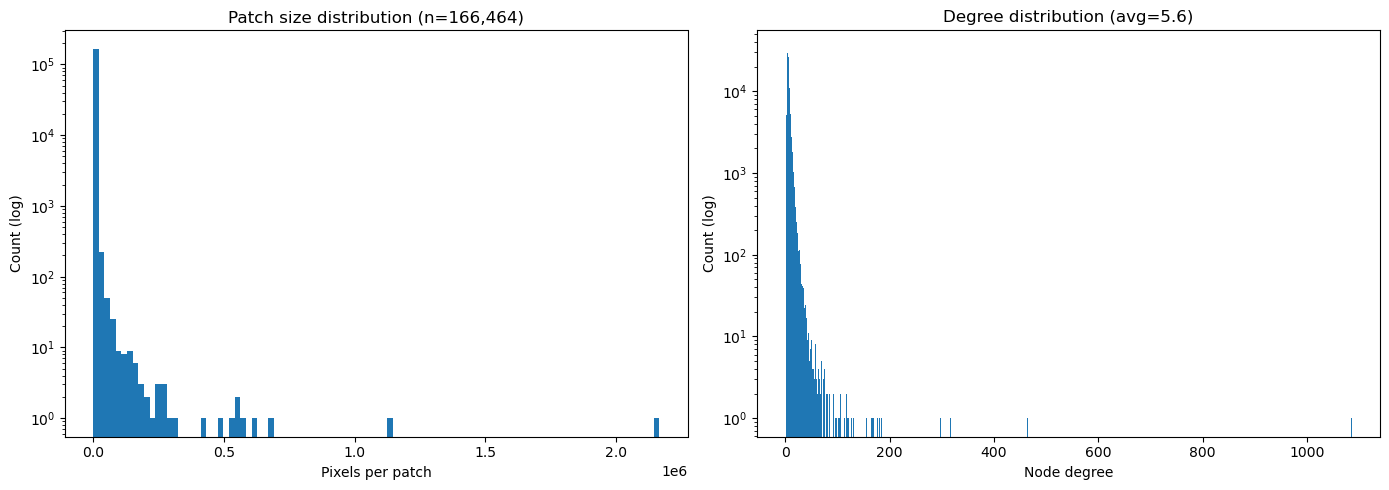

In [8]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(patch_counts[patch_counts > 0], bins=100, log=True)
ax1.set_xlabel('Pixels per patch')
ax1.set_ylabel('Count (log)')
ax1.set_title(f'Patch size distribution (n={n_patches:,})')

degrees = [d for _, d in G.degree()]
ax2.hist(degrees, bins=range(max(degrees)+2), log=True)
ax2.set_xlabel('Node degree')
ax2.set_ylabel('Count (log)')
ax2.set_title(f'Degree distribution (avg={np.mean(degrees):.1f})')

plt.tight_layout()
plt.show()


### Visualize patches

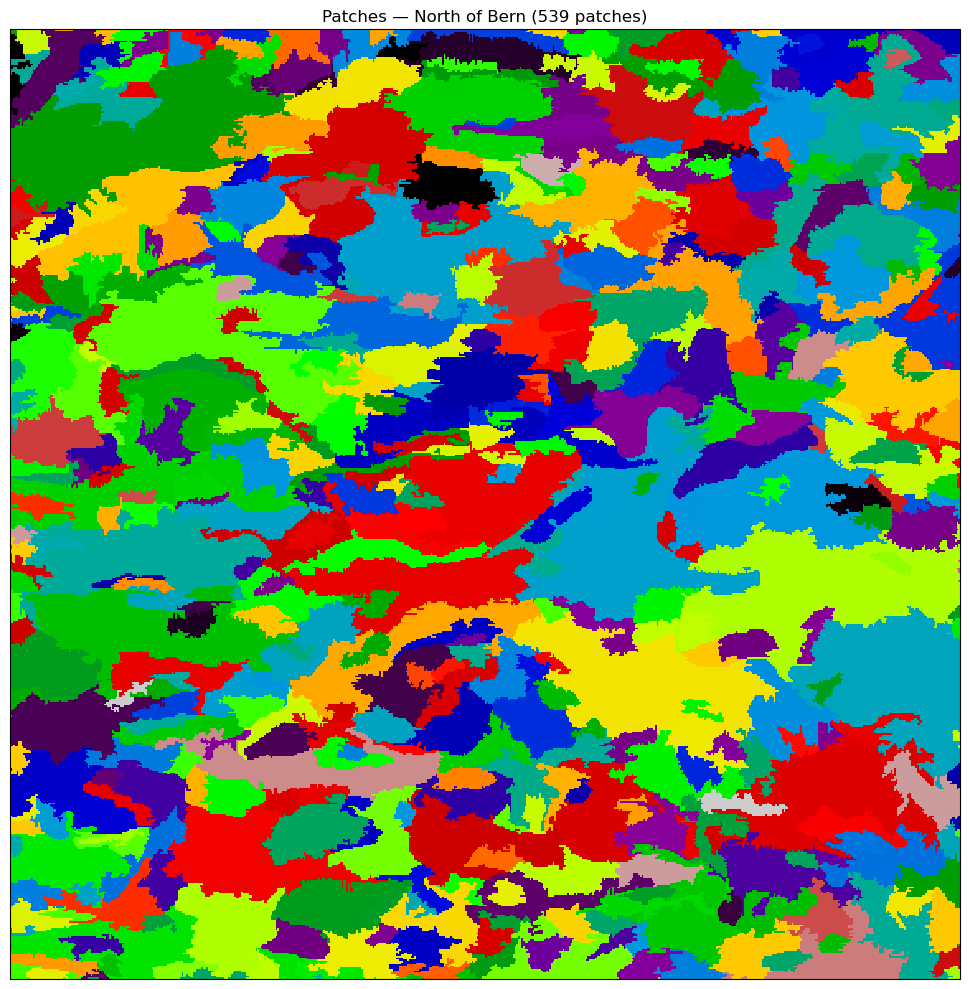

In [15]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from geo_utils import apply_map_decor

roi = {"lon_min": 7.332136, "lon_max": 7.492136,
       "lat_min": 46.880651, "lat_max": 47.040651}

label_roi = xr.DataArray(
    patch_labels, dims=type_da.dims, coords=type_da.coords,
).sel(y=slice(roi['lat_max'], roi['lat_min']),
      x=slice(roi['lon_min'], roi['lon_max']))

# Shuffle colors for visual separation
rng = np.random.default_rng(42)
color_shuffle = rng.permutation(n_patches)
roi_vals = label_roi.values.copy()
v = roi_vals >= 0
roi_vals[v] = color_shuffle[roi_vals[v]]

fig, ax = plt.subplots(figsize=(10, 10),
                       subplot_kw={'projection': ccrs.PlateCarree()})
ax.imshow(roi_vals, cmap='nipy_spectral',
          extent=[roi['lon_min'], roi['lon_max'],
                  roi['lat_min'], roi['lat_max']],
          origin='upper', interpolation='nearest',
          transform=ccrs.PlateCarree())
ax.set_extent([roi['lon_min'], roi['lon_max'],
               roi['lat_min'], roi['lat_max']])
ax.set_title(f'Patches — North of Bern ({len(np.unique(label_roi.values[v])):,} patches)')
plt.tight_layout()
plt.show()

